Анализ сайта "СберАвтоподписка"

In [1]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import re
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

In [3]:
#путь к папке
path = r'C:\Users\eliza\skillbox_diploma'

#sessions
sessions = pd.read_csv(
    f'{path}\\ga_sessions.csv',
    low_memory=False
)

In [4]:
#hits
chunks = []

for chunk in pd.read_csv(
    r'C:\Users\eliza\skillbox_diploma\ga_hits-003.csv',
    chunksize=100000
):
    chunks.append(chunk)
    break  

hits = pd.concat(chunks)

In [5]:
sessions.head()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [6]:
hits.head()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [6]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [8]:
hits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   session_id      100000 non-null  object 
 1   hit_date        100000 non-null  object 
 2   hit_time        100000 non-null  float64
 3   hit_number      100000 non-null  int64  
 4   hit_type        100000 non-null  object 
 5   hit_referer     4632 non-null    object 
 6   hit_page_path   100000 non-null  object 
 7   event_category  100000 non-null  object 
 8   event_action    100000 non-null  object 
 9   event_label     47684 non-null   object 
 10  event_value     0 non-null       float64
dtypes: float64(2), int64(1), object(8)
memory usage: 8.4+ MB


In [7]:
sessions.describe(include='all')

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
count,1860042,1860042,1860042,1860042,1.860042e+06,1859945,1860042,1640439,1524427,777981,1860042,789904,1492864,16338,1860042,1860042,1860042,1860042
unique,1860042,1391719,226,85318,NaN,293,56,412,286,1219,3,13,205,104,5039,57,166,2548
top,9055430416266113553.1640968742.1640968742,1750498477.1629450062,2021-05-24,12:00:00,NaN,ZpYIoDJMcFzVoPFsHGJL,banner,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Apple,AuMdmADEIoPXiWpTsBEj,414x896,Chrome,Russia,Moscow
freq,1,462,39453,61067,NaN,578290,552272,463481,1006599,506819,1474871,464054,551088,9778,169090,1013436,1800565,805329
mean,NaN,NaN,NaN,NaN,2.712804e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,1.182907e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
hits.describe(include='all')

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
count,100000,100000,1.000000e+05,100000.000000,100000,4632,100000,100000,100000,47684,0.0
unique,47293,17,NaN,NaN,1,1454,12931,29,133,2248,NaN
top,3421843301545268943.1639295446.1639295446,2021-11-17,NaN,NaN,event,FwdMTcXzWAwhtsnMAbhS,sberauto.com/cars?utm_source_initial=sbol&utm_...,card_web,view_new_card,hAHqGICPFQiPwtzubOzs,NaN
freq,50,13029,NaN,NaN,100000,505,17022,37087,17804,10950,NaN
mean,NaN,NaN,2.114317e+05,24.333390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,3.867225e+05,28.288878,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,0.000000e+00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,3.393575e+04,8.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,9.793650e+04,16.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2.244748e+05,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
#Проверяем пропуски
sessions.isna().sum().sort_values(ascending=False)
hits.isna().sum().sort_values(ascending=False)

event_value       100000
hit_referer        95368
event_label        52316
hit_time               0
hit_date               0
session_id             0
hit_number             0
hit_page_path          0
hit_type               0
event_action           0
event_category         0
dtype: int64

In [9]:
#Проверяем дубли
sessions.duplicated().sum()

np.int64(0)

In [10]:
hits.duplicated().sum()

np.int64(0)

Данные представлены двумя таблицами:
- sessions — информация о визитах пользователей (1 строка = 1 визит), содержит 1 860 042 строки и 18 признаков;
- hits — информация о действиях пользователей (1 строка = 1 событие), в анализе используется подвыборка из 100 000 строк.

Таблицы связаны между собой по ключу session_id.

In [11]:
#В данных присутствуют некорректные типы: даты и время представлены в формате object.
#Для дальнейшего анализа приводим типы данных к datetime.
sessions['visit_date'] = pd.to_datetime(sessions['visit_date'])

sessions['visit_time'] = pd.to_datetime(
    sessions['visit_time'],
    format='%H:%M:%S',
    errors='coerce'
).dt.time

hits['hit_date'] = pd.to_datetime(hits['hit_date'])

In [12]:
#В данных обнаружены пропуски в ряде признаков:
# - маркетинговые атрибуты (utm_*) содержат пропуски, что соответствует реальным сценариям отсутствия разметки;
# - технические параметры устройств также частично отсутствуют.
#Полностью пустой признак event_value не несёт информации, поэтому его удаляем.
hits = hits.drop(columns=['event_value'], errors='ignore')

Дубликаты в данных отсутствуют, поэтому этот шаг пропускаем.

In [13]:
#Проверяем распределение по типу устройства
sessions['device_category'].value_counts(normalize=True)

device_category
mobile     0.792923
desktop    0.197234
tablet     0.009843
Name: proportion, dtype: float64

Основной объём трафика формируется за счёт рекламных каналов (banner, cpc, cpm).

Органический трафик и прямые заходы (none) также составляют значимую долю.

Наличие значительной доли как платного, так и органического трафика позволяет провести сравнение их эффективности с точки зрения конверсии.
Таким образом:
- трафик преимущественно мобильный;
- основная аудитория сосредоточена в крупнейших городах;
- значительная часть трафика привлекается через платные каналы.

Эти особенности будут учтены при дальнейшей проверке гипотез и анализе эффективности каналов привлечения.

In [14]:
#Проверяем распределение по географии 
sessions['geo_city'].value_counts().head(10)

geo_city
Moscow              805329
Saint Petersburg    296788
(not set)            78172
Yekaterinburg        35788
Krasnodar            32243
Kazan                29531
Samara               24992
Nizhny Novgorod      22227
Ufa                  21679
Novosibirsk          21568
Name: count, dtype: int64

Основной трафик сосредоточен в крупных городах:
- Москва (~43% всех визитов);
- Санкт-Петербург (~16%).

Также присутствует значительная доля пользователей из других крупных региональных центров.
В данных присутствует значение "(not set)", что может свидетельствовать о проблемах с определением геолокации.
Выраженная концентрация трафика в Москве и Санкт-Петербурге позволяет проверить гипотезу о различиях в конверсии между регионами присутствия и другими регионами.

In [16]:
#Проверяем источники трафика
sessions['utm_source'].value_counts().head(10)
sessions['utm_medium'].value_counts().head(10)

utm_medium
banner      552272
cpc         434794
(none)      300575
cpm         242083
referral    152050
organic      63034
email        29240
push         28035
stories      10582
cpv           8022
Name: count, dtype: int64

Большая часть трафика (около 79%) приходится на мобильные устройства.

Доля десктопного трафика составляет около 20%, планшеты занимают незначительную долю (~1%).

Это указывает на выраженную мобильную ориентацию пользователей сервиса.

С учётом высокой доли мобильного трафика особое внимание следует уделять мобильной версии сайта и пользовательскому опыту на мобильных устройствах.

In [17]:
#Определяем целевые события
target_events = [
    'sub_car_claim_click',
    'sub_car_claim_submit_click',
    'sub_open_dialog_click',
    'sub_custom_question_submit_click',
    'sub_call_number_click',
    'sub_callback_submit_click',
    'sub_submit_success',
    'sub_car_request_submit_click'
]

In [18]:
#Находим целевые события
target_hits = hits[hits['event_action'].isin(target_events)]
target_hits['event_action'].value_counts()

event_action
sub_car_claim_click                 167
sub_submit_success                  117
sub_open_dialog_click                79
sub_car_claim_submit_click           67
sub_car_request_submit_click         11
sub_callback_submit_click            11
sub_call_number_click                 9
sub_custom_question_submit_click      2
Name: count, dtype: int64

In [19]:
#Переходим на уровень сессий
converted_sessions = target_hits['session_id'].unique()

In [20]:
#Добавляем флаг в sessions
sessions['is_converted'] = sessions['session_id'].isin(converted_sessions)

In [21]:
#Считаем общий CR
#Для расчёта конверсии использовалась подвыборка событий, что может приводить к занижению абсолютного значения CR.
#Однако это не влияет на сравнительный анализ групп (гипотезы).
cr = sessions['is_converted'].mean()
print('CR =', cr)

CR = 0.0002145112852290432


In [22]:
#Создаем признаки
organic_list = ['organic', 'referral', '(none)']

sessions['traffic_type'] = sessions['utm_medium'].apply(
    lambda x: 'organic' if x in organic_list else 'paid'
)
sessions['traffic_type'].value_counts(normalize=True)

traffic_type
paid       0.72277
organic    0.27723
Name: proportion, dtype: float64

In [23]:
sessions.groupby('traffic_type')['is_converted'].mean()

traffic_type
organic    0.000122
paid       0.000250
Name: is_converted, dtype: float64

На предварительном этапе анализа было рассчитано значение конверсии (CR) по различным типам трафика.

Полученные значения показывают, что:
- CR для платного трафика составляет 0.000250;
- CR для органического трафика составляет 0.000122.

Таким образом, наблюдается более высокий уровень конверсии у платного трафика.
Для проверки статистической значимости различий проведём тестирование гипотезы.

In [24]:
#Проверяем гипотезу №1 при помощи z-теста пропорций.
#H0: конверсия органического и платного трафика не различается.
#H1: конверсия органического и платного трафика различается.

# считаем успехи и наблюдения
conv = sessions.groupby('traffic_type')['is_converted'].sum()
nobs = sessions.groupby('traffic_type')['is_converted'].count()

# порядок: [organic, paid]
successes = [conv['organic'], conv['paid']]
observations = [nobs['organic'], nobs['paid']]

stat, p_value = proportions_ztest(successes, observations)

print('stat:', stat)
print('p-value:', p_value)

stat: -5.325751571128771
p-value: 1.0053646225252951e-07


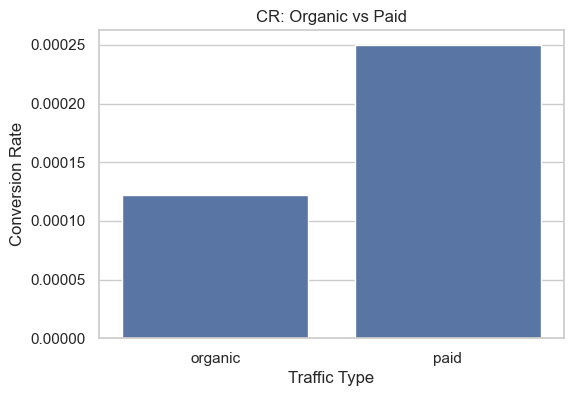

In [25]:
cr_traffic = sessions.groupby('traffic_type')['is_converted'].mean().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=cr_traffic, x='traffic_type', y='is_converted')

plt.title('CR: Organic vs Paid')
plt.ylabel('Conversion Rate')
plt.xlabel('Traffic Type')

plt.show()

На графике видно, что конверсия платного трафика выше органического, что подтверждает результаты статистического теста.

Гипотеза №1.

H0: конверсия органического и платного трафика не различается.

H1: конверсия органического и платного трафика различается.

Метод: Для проверки гипотезы был использован z-тест для сравнения долей (proportions z-test), так как сравниваются две независимые выборки по бинарному признаку (наличие/отсутствие конверсии).

Результат: В результате теста было получено значение p-value = 1.0e-07. Это позволяет отвергнуть нулевую гипотезу.

Интерпретация: Таким образом, различия в конверсии между органическим и платным трафиком являются статистически значимыми. При этом платный трафик демонстрирует более высокий уровень конверсии.

Платный трафик является более эффективным с точки зрения привлечения пользователей, совершающих целевые действия. Это может свидетельствовать о более точном таргетировании или высокой релевантности рекламных кампаний.
Следует учитывать, что анализ проведён на подвыборке данных, что может влиять на абсолютные значения метрик, однако не искажает сравнительный характер выводов.

In [28]:
#Проверяем гипотезу №2 при помощи z-теста пропорций.
#H0: конверсия пользователей мобильных и десктопных устройств не различается
#H1: конверсия пользователей мобильных и десктопных устройств различается

# считаем успехи и наблюдения
conv = sessions.groupby('device_category')['is_converted'].sum()
nobs = sessions.groupby('device_category')['is_converted'].count()

# порядок: [mobile, desktop]
successes = [conv['mobile'], conv['desktop']]
observations = [nobs['mobile'], nobs['desktop']]

stat, p_value = proportions_ztest(successes, observations)

print('stat:', stat)
print('p-value:', p_value)

stat: 2.6709249136854547
p-value: 0.007564256538147165


In [43]:
#Смотрим трафик по CR
sessions.groupby('device_category').size()

device_category
desktop     366863
mobile     1474871
tablet       18308
dtype: int64

In [44]:
#Смотрим CR
sessions.groupby('device_category')['is_converted'].mean()

device_category
desktop    0.000158
mobile     0.000231
tablet     0.000055
Name: is_converted, dtype: float64

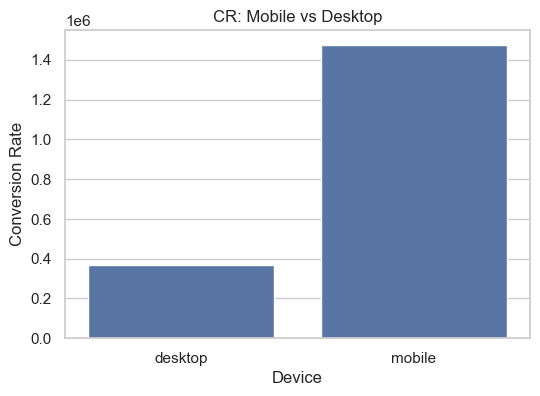

In [48]:
cr_device = sessions[sessions['device_category'].isin(['mobile', 'desktop'])] \
    .groupby('device_category')['is_converted'].size().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=cr_device, x='device_category', y='is_converted')

plt.title('CR: Mobile vs Desktop')
plt.ylabel('Conversion Rate')
plt.xlabel('Device')

plt.show()

Наблюдаются различия в конверсии между мобильными и десктопными устройствами, что также подтверждается статистическим тестом.

Гипотеза №2.

H0: конверсия пользователей мобильных и десктопных устройств не различается.

H1: конверсия пользователей мобильных и десктопных устройств различается.

Метод: Для проверки гипотезы был использован z-тест для сравнения долей, так как сравниваются две независимые выборки по бинарному признаку.

Результат: В результате теста было получено значение p-value = 0.0076, что меньше уровня значимости 0.05. Это позволяет отвергнуть нулевую гипотезу.

Интерпретация: Таким образом, различия в конверсии между мобильными и десктопными пользователями являются статистически значимыми. 
Пользователи мобильных устройств демонстрируют более высокую конверсию, что может свидетельствовать о хорошем качестве мобильной версии сайта.

In [30]:
#Проверяем гипотезу №3 при помощи z-теста пропорций.
#H0: CR в городах присутствия (Москва и СПб) и других регионах одинаковый.
#H1: CR в городах присутствия (Москва и СПб) и других регионах различается.

#создаем признак
sessions['is_main_city'] = sessions['geo_city'].apply(
    lambda x: 'main' if x in ['Moscow', 'Saint Petersburg'] else 'other'
)

conv = sessions.groupby('is_main_city')['is_converted'].sum()
nobs = sessions.groupby('is_main_city')['is_converted'].count()

# порядок: [main, other]
successes = [conv['main'], conv['other']]
observations = [nobs['main'], nobs['other']]

stat, p_value = proportions_ztest(successes, observations)

print('stat:', stat)
print('p-value:', p_value)

stat: -1.0614001954174275
p-value: 0.2885080681508557


In [45]:
#Смотрим CR
sessions.groupby('is_main_city')['is_converted'].mean()

is_main_city
main     0.000205
other    0.000228
Name: is_converted, dtype: float64

In [46]:
#Смитрим трафик по CR
sessions.groupby('is_main_city')['is_converted'].size()

is_main_city
main     1102117
other     757925
Name: is_converted, dtype: int64

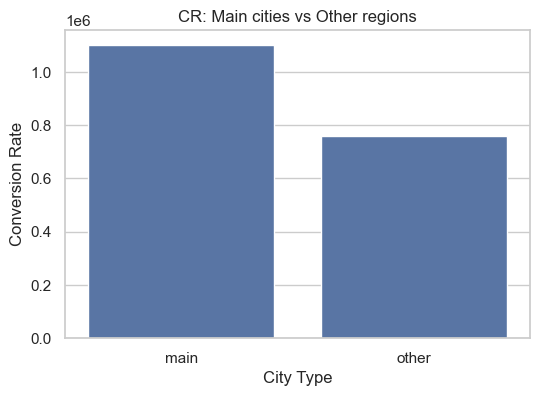

In [47]:
cr_city = sessions.groupby('is_main_city')['is_converted'].size().reset_index()

plt.figure(figsize=(6,4))
sns.barplot(data=cr_city, x='is_main_city', y='is_converted')

plt.title('CR: Main cities vs Other regions')
plt.ylabel('Conversion Rate')
plt.xlabel('City Type')

plt.show()

На графике различия между группами практически не заметны, что согласуется с результатами статистического теста.

H0: CR в городах присутствия (Москва и СПб) и других регионах одинаковый.

H1: CR в городах присутствия (Москва и СПб) и других регионах различается.

Метод: для проверки гипотезы использован z-тест для сравнения долей, так как сравниваются две независимые выборки по бинарному признаку.

Результат: в результате теста было получено значение p-value = 0.2885, что превышает уровень значимости 0.05.

Вывод: nаким образом, не удалось отвергнуть нулевую гипотезу. Статистически значимых различий в конверсии между пользователями из городов присутствия и других регионов не обнаружено.
Географическое положение (в рамках сравнения городов присутствия и остальных регионов) не оказывает значимого влияния на вероятность совершения целевого действия.
Это может означать, что продукт одинаково воспринимается пользователями вне зависимости от региона.

In [33]:
#Из каких источников идёт самый целевой трафик?
#Проверяем объем + CR
sessions.groupby('utm_source').agg({
    'session_id': 'count',
    'is_converted': 'mean'
}).sort_values(by='is_converted', ascending=False).head(10)

,session_id,is_converted
utm_source,,
juYouSPHPfKdXivEPJjt,6,0.166667
QxAxdyPLuQMEcrdZWdWb,51415,0.000739
nrKihqcWGIzDsOqljdAv,1670,0.000599
GpAkIXsclxDGyILfNlrR,2116,0.000473
ISrKoXQCxqqYvAZICvjs,8633,0.000463
gVRrcxiDQubJiljoTbGm,2767,0.000361
ZpYIoDJMcFzVoPFsHGJL,578290,0.000322
oZCzWSykfixnjMPDNjSU,3143,0.000318
iNFgfQPqHPBuvGCYtrQE,3532,0.000283


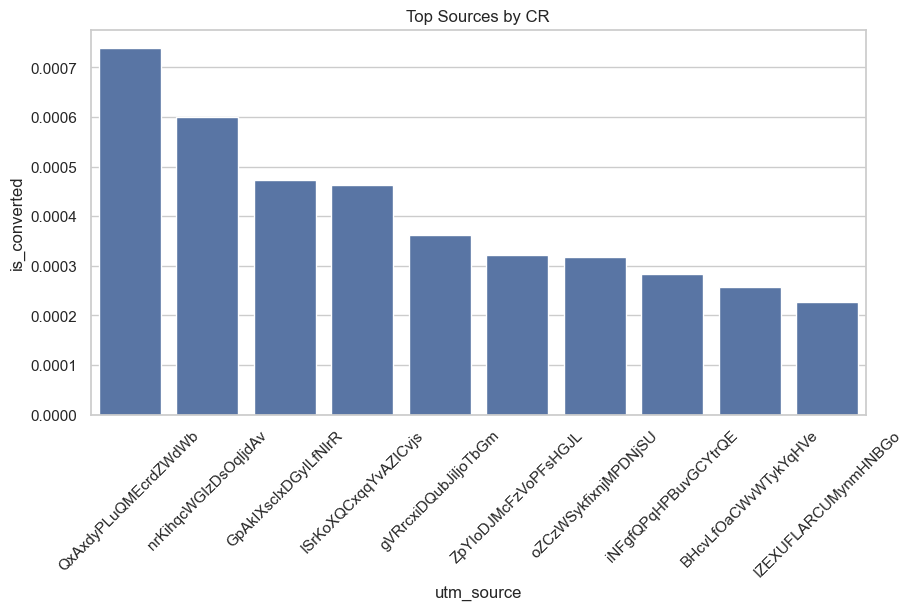

In [34]:
source_stats = sessions.groupby('utm_source').agg({
    'session_id': 'count',
    'is_converted': 'mean'
}).reset_index()

# фильтр по объёму
source_stats = source_stats[source_stats['session_id'] > 1000]

top_sources = source_stats.sort_values(by='is_converted', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_sources, x='utm_source', y='is_converted')

plt.xticks(rotation=45)
plt.title('Top Sources by CR')

plt.show()

Анализ источников трафика показал, что:
- наибольший объём трафика привлекается из источника ZpYIoDJMcFzVoPFsHGJL;
- наиболее высокий уровень конверсии среди источников с существенным объёмом трафика демонстрируют QxAxdyPLuQMEcrdZWdWb и nrKihqcWGIzDsOqljdAv.

При этом источники с крайне малым количеством визитов могут показывать аномально высокий CR, однако такие значения не являются надёжными для принятия решений.

Таким образом, основной вклад в привлечение пользователей обеспечивает источник с наибольшим объёмом трафика, однако с точки зрения эффективности более перспективными являются источники с более высоким уровнем конверсии
Это указывает на необходимость оптимизации маркетинговых бюджетов с учётом не только объёма, но и качества трафика.

In [35]:
#Какие авто пользуются спросом?
hits['hit_page_path'].value_counts().head(10)

hit_page_path
sberauto.com/cars?utm_source_initial=sbol&utm_medium_initial=banner&utm_campaign_initial=LEoPHuyFvzoNfnzGgfcd&utm_content_initial=vCIpmpaGBnIQhyYNkXqp&city=1&rental_page=rental_only&rental_car=rental_only&city=18    17022
podpiska.sberauto.com/                                                                                                                                                                                                  15350
sberauto.com/cars?city=1&rental_page=rental_only&rental_car=rental_only&city=18                                                                                                                                          3738
sberauto.com/cars/nissan?rental_car=rental_only&rental_page=rental_only                                                                                                                                                  3270
sberauto.com/cars/all/lada-vaz/vesta/2fc745ed?rental_page=rental_car                              

In [36]:
def extract_brand(url):
    if pd.isna(url):
        return None
    
    match = re.search(r'/cars/all/([^/]+)/', url)
    if match:
        return match.group(1)
    
    return None

hits['car_brand'] = hits['hit_page_path'].apply(extract_brand)

In [37]:
#Самые популярные авто
hits['car_brand'].value_counts().head(10)

car_brand
skoda            8410
mercedes-benz    5020
lada-vaz         4892
volkswagen       4828
kia              3273
nissan           2732
bmw              2339
toyota           1647
renault          1634
lexus             805
Name: count, dtype: int64

In [38]:
merged = hits.merge(
    sessions[['session_id', 'is_converted']],
    on='session_id',
    how='left'
)

In [39]:
#Считаем CR по брендам
car_stats = merged.groupby('car_brand').agg({
    'session_id': 'count',
    'is_converted': 'mean'
}).sort_values(by='is_converted', ascending=False)
car_stats = car_stats[car_stats['session_id'] > 100]

car_stats.head(10)

,session_id,is_converted
car_brand,,
toyota,1647,0.044832
kia,3273,0.039531
volkswagen,4828,0.027877
haval,759,0.027668
skoda,8410,0.025632
lada-vaz,4892,0.023697
bmw,2339,0.017133
renault,1634,0.016749
peugeot,379,0.015831


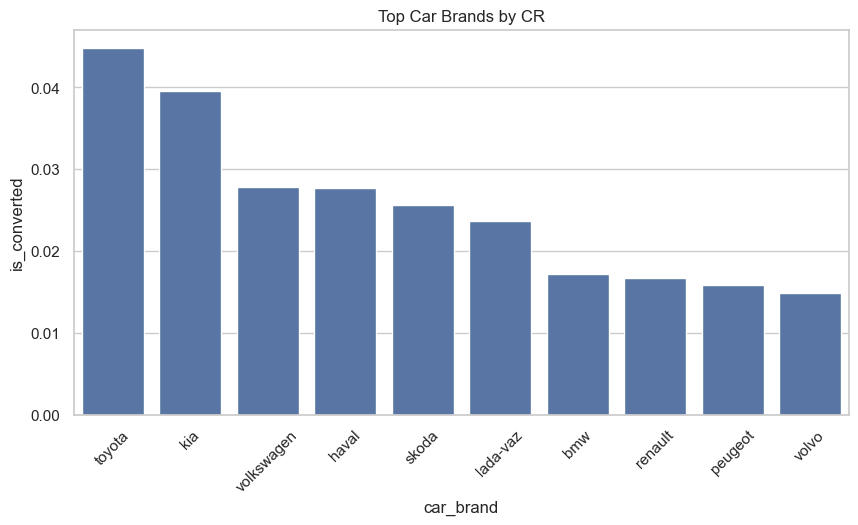

In [41]:
car_stats = merged.groupby('car_brand').agg({
    'session_id': 'count',
    'is_converted': 'mean'
}).reset_index()

car_stats = car_stats[car_stats['session_id'] > 100]
top_cars = car_stats.sort_values(by='is_converted', ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top_cars, x='car_brand', y='is_converted')

plt.xticks(rotation=45)
plt.title('Top Car Brands by CR')

plt.show()

Анализ пользовательского поведения показал, что наибольшим спросом пользуются автомобили следующих марок:
- Skoda;
- Lada (ВАЗ);
- Volkswagen;
- Kia.

При этом наибольший уровень конверсии демонстрируют:
- Toyota (~4.5%);
- Kia (~4.0%);
- Volkswagen (~2.8%).

Таким образом, наиболее популярные автомобили не всегда являются наиболее конверсионными.
Это может свидетельствовать о различии между интересом пользователей и их готовностью совершить целевое действие.
Полученные результаты позволяют выделить два направления для оптимизации:
- усиление продвижения автомобилей с высокой конверсией (например, Toyota, Kia);
- анализ и улучшение пользовательского опыта для популярных, но менее конверсионных моделей (например, Skoda).

In [77]:
#Стоит ли увеличивать присутствие в соцсетях и давать там больше рекламы?
sessions.groupby('utm_medium')['is_converted'].agg(['count', 'mean']).sort_values(by='mean', ascending=False)

,count,mean
utm_medium,,
(not set),480,0.002083
smm,1985,0.002015
smartbanner,6794,0.001619
banner,552272,0.000308
cpc,434794,0.000271
cpa,4279,0.000234
push,28035,0.000214
referral,152050,0.000138
blogger_channel,8015,0.000125


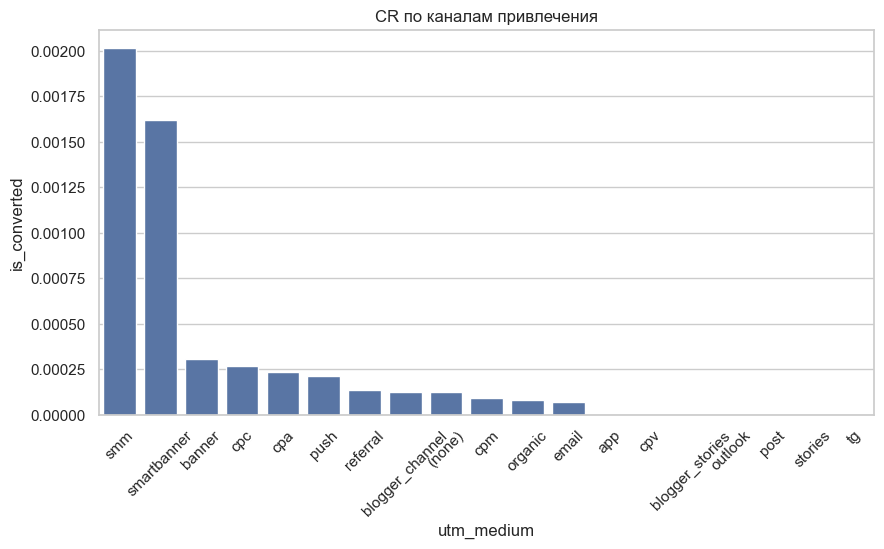

In [49]:
channel_stats = sessions.groupby('utm_medium').agg({
    'session_id': 'count',
    'is_converted': 'mean'
}).reset_index()

channel_stats = channel_stats[channel_stats['session_id'] > 1000]

top_channels = channel_stats.sort_values(by='is_converted', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(data=top_channels, x='utm_medium', y='is_converted')

plt.xticks(rotation=45)
plt.title('CR по каналам привлечения')

plt.show()

Анализ каналов привлечения показал, что:
- наибольший объём трафика обеспечивают каналы banner и cpc;
- наибольшую конверсию демонстрируют каналы smm и smartbanner, однако их объём значительно ниже.
При этом каналы, относящиеся к социальным сетям (vk_smm, fb_smm, blogger и др.), демонстрируют нулевую конверсию.
Однако данные результаты не позволяют сделать однозначный вывод об эффективности данных каналов по следующим причинам:
- малый объём трафика по отдельным каналам;
- использование подвыборки данных;
- возможные проблемы с атрибуцией трафика (наличие значений "(none)" и "(not set)").
Таким образом, на основании имеющихся данных нельзя сделать вывод о необходимости увеличения или сокращения инвестиций в социальные сети.
Для принятия решения требуется дополнительный анализ с использованием полного набора данных и корректной атрибуции каналов.

Заключение

В рамках данной работы был проведён анализ пользовательского поведения на сайте сервиса, направленного на подбор и оформление автомобилей.

На первом этапе была выполнена подготовка данных: проведена очистка, обработка пропусков, приведение типов данных, а также исследование структуры и распределений ключевых признаков. Анализ показал, что основной трафик приходится на мобильные устройства, а пользователи в значительной степени сосредоточены в крупнейших городах. Также было выявлено преобладание платных каналов привлечения трафика.

Далее был рассчитан ключевой показатель эффективности — конверсия (Conversion Rate), определяемая как доля сессий, в рамках которых было совершено хотя бы одно целевое действие. На основе этого показателя проведена проверка трёх гипотез.

В результате проверки гипотез было установлено:

- конверсия платного трафика статистически значимо выше, чем органического, что свидетельствует о большей эффективности платных каналов привлечения;
- конверсия пользователей мобильных и десктопных устройств также различается статистически значимо, что указывает на влияние типа устройства на поведение пользователей;
- различия в конверсии между пользователями из городов присутствия и других регионов не являются статистически значимыми, что позволяет говорить об отсутствии выраженного влияния географического фактора.

В рамках ответа на вопросы продуктовой команды было выявлено, что:
- ключевой объём трафика обеспечивают отдельные источники с большим количеством визитов, однако наиболее эффективные с точки зрения конверсии источники могут отличаться;
- наиболее популярные автомобили не всегда обладают наивысшей конверсией: часть моделей привлекает значительный интерес пользователей, но конвертируется хуже, чем менее популярные аналоги;
- каналы, связанные с социальными сетями, демонстрируют низкие показатели конверсии, однако из-за ограничений данных и возможных проблем с атрибуцией нельзя сделать однозначный вывод об их эффективности.

Таким образом, результаты анализа позволяют сформулировать следующие рекомендации:
- учитывать не только объём трафика, но и его качество при распределении маркетингового бюджета;
- усиливать продвижение высококонверсионных моделей автомобилей;
- оптимизировать пользовательский опыт для популярных, но менее конверсионных предложений;
- провести дополнительный анализ каналов привлечения с использованием более полного и корректно размеченного набора данных.

Следует отметить, что анализ проводился на подвыборке данных, что может влиять на абсолютные значения показателей, однако не искажает общие закономерности и сравнительные выводы.
В целом проведённое исследование позволяет лучше понять поведение пользователей и может быть использовано для принятия продуктовых и маркетинговых решений.